# Data Cleaning

3. Empty Manipulation

In [1]:
import pandas as pd

In [2]:
titanic_df = pd.read_csv('titanic.csv')

In [3]:
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
titanic_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [5]:
titanic_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Handling Null/NaN/NA values

In [6]:
titanic_df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
# intitals = []
# for name in titanic_df.Name:
#     initi = name.split(",")[-1].split(".")[0].strip()
#     intitals.append(initi)
    
# List Comprehensions
intitals = [ name.split(",")[-1].split(".")[0].strip() for name in titanic_df.Name]

In [8]:
# Inserting or replacing Columns

titanic_df.insert(loc = 1, column="initials", value=intitals)
titanic_df.head()

,PassengerId,initials,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,Mr,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,Mrs,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,Miss,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,Mrs,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,Mr,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [9]:
# Inserting or replacing Columns

titanic_df["new_initials"] = intitals
titanic_df.head()

,PassengerId,initials,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,new_initials
0,1,Mr,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr
1,2,Mrs,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs
2,3,Miss,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss
3,4,Mrs,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs
4,5,Mr,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr


# Methods
1. Removing Null Values
2. Fill something (Imputation)
3. Null as New Feature (Feature Engineering)

In [10]:
# 1. Removing Null Values for Embarked
embarked_removed = titanic_df.dropna(
    subset = 'Embarked', axis = 0, ignore_index = True
)
embarked_removed.head()

,PassengerId,initials,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,new_initials
0,1,Mr,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr
1,2,Mrs,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs
2,3,Miss,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss
3,4,Mrs,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs
4,5,Mr,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr


In [11]:
embarked_removed.shape

(889, 14)

In [12]:
embarked_removed.isna().sum()

PassengerId       0
initials          0
Survived          0
Pclass            0
Name              0
Sex               0
Age             177
SibSp             0
Parch             0
Ticket            0
Fare              0
Cabin           687
Embarked          0
new_initials      0
dtype: int64

In [13]:
# 2. Null as New Feature (Feature Engineering)
embarked_removed["Cabin"] = embarked_removed.Cabin.notna().astype(int)

embarked_removed.head()

,PassengerId,initials,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,new_initials
0,1,Mr,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,0,S,Mr
1,2,Mrs,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,1,C,Mrs
2,3,Miss,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,0,S,Miss
3,4,Mrs,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,1,S,Mrs
4,5,Mr,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,0,S,Mr


In [14]:
embarked_removed.isna().sum()

PassengerId       0
initials          0
Survived          0
Pclass            0
Name              0
Sex               0
Age             177
SibSp             0
Parch             0
Ticket            0
Fare              0
Cabin             0
Embarked          0
new_initials      0
dtype: int64

In [15]:
# 3. Fill Null Values or something (Imputation)
print(titanic_df.Age.mean())
print(titanic_df.Age.median())

29.69911764705882
28.0


<Axes: ylabel='Frequency'>

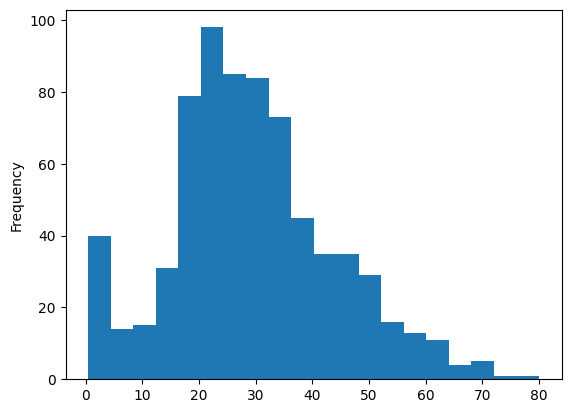

In [16]:
titanic_df.Age.plot(kind='hist', bins = 20)

In [17]:
titanic_df.groupby('Sex')['Age'].mean()

Sex
female    27.915709
male      30.726645
Name: Age, dtype: float64

In [18]:
titanic_df.groupby('Sex')['Age'].median()

Sex
female    27.0
male      29.0
Name: Age, dtype: float64

In [19]:
median_replace_df = embarked_removed.copy()

med_age = embarked_removed.Age.median()
median_replace_df['Age'] =  median_replace_df.Age.fillna(value=med_age, axis=0)

# median_replace_df.Age.plot(kind = 'hist', bins = 20)

In [20]:
median_replace_df.isna().sum()

PassengerId     0
initials        0
Survived        0
Pclass          0
Name            0
Sex             0
Age             0
SibSp           0
Parch           0
Ticket          0
Fare            0
Cabin           0
Embarked        0
new_initials    0
dtype: int64

29.315151856017994
28.0


<Axes: ylabel='Frequency'>

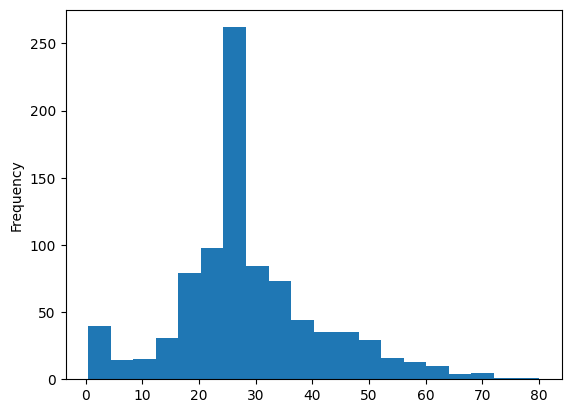

In [21]:
print(median_replace_df.Age.mean())
print(median_replace_df.Age.median())

median_replace_df.Age.plot(kind="hist", bins = 20)

In [22]:
male_med = embarked_removed[embarked_removed.Sex == 'male'].Age.median()
female_med = embarked_removed[embarked_removed.Sex == 'female'].Age.median()

male_med, female_med

(np.float64(29.0), np.float64(27.0))

In [23]:
grouped_object = embarked_removed.groupby(by = 'Sex')
med_age = grouped_object.Age.transform('median')

In [24]:
median_gender_df = embarked_removed.copy()
median_gender_df['Age'] =  median_gender_df.Age.fillna(value=med_age, axis=0)

29.395016872890885
29.0


<Axes: ylabel='Frequency'>

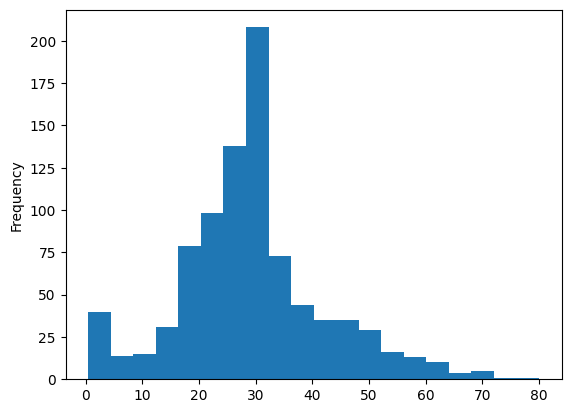

In [25]:
print(median_gender_df.Age.mean())
print(median_gender_df.Age.median())

median_gender_df.Age.plot(kind = 'hist', bins = 20)

In [26]:
# Imputation Age wrt Initials

embarked_removed.initials.value_counts()

initials
Mr              517
Miss            181
Mrs             124
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don               1
Mme               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

In [27]:
titanic_df.head()

,PassengerId,initials,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,new_initials
0,1,Mr,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr
1,2,Mrs,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs
2,3,Miss,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss
3,4,Mrs,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs
4,5,Mr,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr


In [28]:
# replacing with .replace() method

embarked_removed.initials = embarked_removed.initials.replace(
    to_replace="Dr", value="Mr"
)

In [29]:
embarked_removed.initials = embarked_removed.initials.replace(
    to_replace=["Rev", "Don","Sir", "Col", "Capt","Major"], value="Mr"
)

In [30]:
embarked_removed.loc[:, "initials"] = embarked_removed.initials.replace(
    to_replace= {
        "Mlle": "Miss", "Mme": "Mrs", "Ms": "Miss", "Lady": "Miss", "the Countess" : "Miss", "Jonkheer" : "Master"
    }
)

In [31]:
median_age = embarked_removed.groupby(by = "initials").Age.transform("median")
median_age

0      30.0
1      35.0
2      21.5
3      35.0
4      30.0
       ... 
884    30.0
885    21.5
886    21.5
887    30.0
888    30.0
Name: Age, Length: 889, dtype: float64

In [32]:
median_initial_df = embarked_removed.copy()

median_initial_df["Age"] = median_initial_df.Age.fillna(
    value= median_age, axis=0
)

29.347772778402696
30.0


<Axes: ylabel='Frequency'>

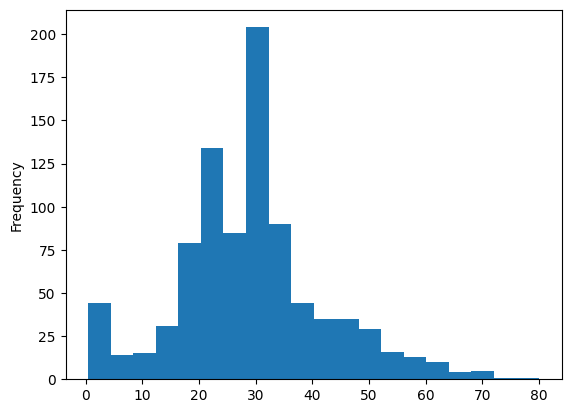

In [33]:
print(median_initial_df.Age.mean())
print(median_initial_df.Age.median())

median_initial_df.Age.plot(kind="hist", bins = 20)

In [34]:
median_initial_df.head()

,PassengerId,initials,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,new_initials
0,1,Mr,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,0,S,Mr
1,2,Mrs,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,1,C,Mrs
2,3,Miss,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,0,S,Miss
3,4,Mrs,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,1,S,Mrs
4,5,Mr,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,0,S,Mr


## Managing Duplicates


In [ ]:
# Creating Duplicate/ inserting duplicate row
median_initial_df.loc[900, :] = median_initial_df.loc[0,:]

In [36]:
median_initial_df

,PassengerId,initials,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,new_initials
0,1.0,Mr,0.0,3.0,"Braund, Mr. Owen Harris",male,22.0,1.0,0.0,A/5 21171,7.2500,0.0,S,Mr
1,2.0,Mrs,1.0,1.0,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1.0,0.0,PC 17599,71.2833,1.0,C,Mrs
2,3.0,Miss,1.0,3.0,"Heikkinen, Miss. Laina",female,26.0,0.0,0.0,STON/O2. 3101282,7.9250,0.0,S,Miss
3,4.0,Mrs,1.0,1.0,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1.0,0.0,113803,53.1000,1.0,S,Mrs
4,5.0,Mr,0.0,3.0,"Allen, Mr. William Henry",male,35.0,0.0,0.0,373450,8.0500,0.0,S,Mr
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,888.0,Miss,1.0,1.0,"Graham, Miss. Margaret Edith",female,19.0,0.0,0.0,112053,30.0000,1.0,S,Miss
886,889.0,Miss,0.0,3.0,"Johnston, Miss. Catherine Helen ""Carrie""",female,21.5,1.0,2.0,W./C. 6607,23.4500,0.0,S,Miss
887,890.0,Mr,1.0,1.0,"Behr, Mr. Karl Howell",male,26.0,0.0,0.0,111369,30.0000,1.0,C,Mr
888,891.0,Mr,0.0,3.0,"Dooley, Mr. Patrick",male,32.0,0.0,0.0,370376,7.7500,0.0,Q,Mr


In [37]:
median_initial_df[median_initial_df.duplicated(subset="Name")]

,PassengerId,initials,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,new_initials
900,1.0,Mr,0.0,3.0,"Braund, Mr. Owen Harris",male,22.0,1.0,0.0,A/5 21171,7.25,0.0,S,Mr


In [38]:
median_initial_df[median_initial_df.duplicated()]

,PassengerId,initials,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,new_initials
900,1.0,Mr,0.0,3.0,"Braund, Mr. Owen Harris",male,22.0,1.0,0.0,A/5 21171,7.25,0.0,S,Mr


In [ ]:
# Dropping Duplicate Row
median_initial_df.drop_duplicates(subset="Name", inplace=True)

In [40]:
median_initial_df.tail()

,PassengerId,initials,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,new_initials
884,887.0,Mr,0.0,2.0,"Montvila, Rev. Juozas",male,27.0,0.0,0.0,211536,13.00,0.0,S,Rev
885,888.0,Miss,1.0,1.0,"Graham, Miss. Margaret Edith",female,19.0,0.0,0.0,112053,30.00,1.0,S,Miss
886,889.0,Miss,0.0,3.0,"Johnston, Miss. Catherine Helen ""Carrie""",female,21.5,1.0,2.0,W./C. 6607,23.45,0.0,S,Miss
887,890.0,Mr,1.0,1.0,"Behr, Mr. Karl Howell",male,26.0,0.0,0.0,111369,30.00,1.0,C,Mr
888,891.0,Mr,0.0,3.0,"Dooley, Mr. Patrick",male,32.0,0.0,0.0,370376,7.75,0.0,Q,Mr


## Data Management

In [ ]:
# Type Conversion
median_initial_df.dtypes

PassengerId     float64
initials            str
Survived           int8
Pclass            int64
Name                str
Sex                 str
Age             float64
SibSp           float64
Parch           float64
Ticket              str
Fare            float64
Cabin              bool
Embarked            str
new_initials        str
dtype: object

In [42]:
median_initial_df["Pclass"] = median_initial_df.Pclass.astype(int)

In [44]:
median_initial_df = median_initial_df.astype(
    {"Survived": "int8", "Cabin": bool}
)

In [46]:
median_initial_df

,PassengerId,initials,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,new_initials
0,1.0,Mr,0,3,"Braund, Mr. Owen Harris",male,22.0,1.0,0.0,A/5 21171,7.2500,False,S,Mr
1,2.0,Mrs,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1.0,0.0,PC 17599,71.2833,True,C,Mrs
2,3.0,Miss,1,3,"Heikkinen, Miss. Laina",female,26.0,0.0,0.0,STON/O2. 3101282,7.9250,False,S,Miss
3,4.0,Mrs,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1.0,0.0,113803,53.1000,True,S,Mrs
4,5.0,Mr,0,3,"Allen, Mr. William Henry",male,35.0,0.0,0.0,373450,8.0500,False,S,Mr
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
884,887.0,Mr,0,2,"Montvila, Rev. Juozas",male,27.0,0.0,0.0,211536,13.0000,False,S,Rev
885,888.0,Miss,1,1,"Graham, Miss. Margaret Edith",female,19.0,0.0,0.0,112053,30.0000,True,S,Miss
886,889.0,Miss,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,21.5,1.0,2.0,W./C. 6607,23.4500,False,S,Miss
887,890.0,Mr,1,1,"Behr, Mr. Karl Howell",male,26.0,0.0,0.0,111369,30.0000,True,C,Mr


## Indexing

In [48]:
# Get Index
median_initial_df.index

Index([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,
       ...
       879, 880, 881, 882, 883, 884, 885, 886, 887, 888],
      dtype='int64', length=889)

In [ ]:
median_initial_df.set_index("Name")

# median_initial_df.index = median_initial_df.index.Name        # copy set_index
# median_initial_df


,PassengerId,initials,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,new_initials
Name,,,,,,,,,,,,,
"Braund, Mr. Owen Harris",1.0,Mr,0,3,male,22.0,1.0,0.0,A/5 21171,7.2500,False,S,Mr
"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",2.0,Mrs,1,1,female,38.0,1.0,0.0,PC 17599,71.2833,True,C,Mrs
"Heikkinen, Miss. Laina",3.0,Miss,1,3,female,26.0,0.0,0.0,STON/O2. 3101282,7.9250,False,S,Miss
"Futrelle, Mrs. Jacques Heath (Lily May Peel)",4.0,Mrs,1,1,female,35.0,1.0,0.0,113803,53.1000,True,S,Mrs
"Allen, Mr. William Henry",5.0,Mr,0,3,male,35.0,0.0,0.0,373450,8.0500,False,S,Mr
...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Montvila, Rev. Juozas",887.0,Mr,0,2,male,27.0,0.0,0.0,211536,13.0000,False,S,Rev
"Graham, Miss. Margaret Edith",888.0,Miss,1,1,female,19.0,0.0,0.0,112053,30.0000,True,S,Miss
"Johnston, Miss. Catherine Helen ""Carrie""",889.0,Miss,0,3,female,21.5,1.0,2.0,W./C. 6607,23.4500,False,S,Miss


## Renaming Columns

In [52]:
median_initial_df['PStatus'] = median_initial_df["Pclass"]
median_initial_df.drop("Pclass", axis = 1, inplace=True)

In [53]:
median_initial_df.rename(
    mapper={"Sex": "Gender"},
    axis=1
)

,PassengerId,initials,Survived,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,new_initials,PStatus
0,1.0,Mr,0,"Braund, Mr. Owen Harris",male,22.0,1.0,0.0,A/5 21171,7.2500,False,S,Mr,3
1,2.0,Mrs,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1.0,0.0,PC 17599,71.2833,True,C,Mrs,1
2,3.0,Miss,1,"Heikkinen, Miss. Laina",female,26.0,0.0,0.0,STON/O2. 3101282,7.9250,False,S,Miss,3
3,4.0,Mrs,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1.0,0.0,113803,53.1000,True,S,Mrs,1
4,5.0,Mr,0,"Allen, Mr. William Henry",male,35.0,0.0,0.0,373450,8.0500,False,S,Mr,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
884,887.0,Mr,0,"Montvila, Rev. Juozas",male,27.0,0.0,0.0,211536,13.0000,False,S,Rev,2
885,888.0,Miss,1,"Graham, Miss. Margaret Edith",female,19.0,0.0,0.0,112053,30.0000,True,S,Miss,1
886,889.0,Miss,0,"Johnston, Miss. Catherine Helen ""Carrie""",female,21.5,1.0,2.0,W./C. 6607,23.4500,False,S,Miss,3
887,890.0,Mr,1,"Behr, Mr. Karl Howell",male,26.0,0.0,0.0,111369,30.0000,True,C,Mr,1


## Saving files to csv

In [54]:
median_initial_df.to_csv(
    "Updated_Titanic_Data.csv",
    index=False
)